## Loading the data & data exploration

In [22]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import string
from nltk.corpus import stopwords
import nltk

In [23]:
# Load the CSV file into a DataFrame
df_localization = pd.read_csv('language_analysis/df_localization.csv')

# Display the first rows of the DataFrame
print(df_localization.head())

    productid     imageid  prdtypecode  bool_description  \
0  3804725264  1263597046           10                 0   
1   436067568  1008141237         2280                 0   
2   201115110   938777978           50                 1   
3    50418756   457047496         1280                 0   
4   278535884  1077757786         2705                 1   

                                         merged_text lang  \
0  Olivia: Personalisiertes Notizbuch / 150 Seite...   de   
1  Journal Des Arts Le N° 133 Du 28/09/2001 - L'a...   fr   
2  PILOT STYLE Touch Pen de marque Speedlink est ...   fr   
3  Peluche Donald - Europe - Disneyland 2000 Mari...   fr   
4  La Guerre Des Tuques - Luc a des idées de gran...   fr   

                                   deepL_translation  
0  Olivia : Carnet de notes personnalisé / 150 pa...  
1                                                NaN  
2                                                NaN  
3                                                NaN

## Preprocessing

In [ ]:
# Download the stopwords list if not already downloaded
nltk.download('stopwords')

# Get the French stop words
french_stop_words = set(stopwords.words('french'))

# Function to preprocess text: lowercase, remove punctuation, and remove stop words
def preprocess_text(text):
    if pd.isna(text):  # Handle NaN values
        return ""
    text = text.lower()  # Convert to lowercase, because stopwords are case-sensitive.
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = ' '.join([word for word in text.split() if word not in french_stop_words])  # Remove stop words
    return text

# Create a new DataFrame with the "text" column
df_processed = df_localization.copy()
df_processed['text'] = df_processed.apply(
    lambda row: preprocess_text(row['deepL_translation']) if pd.notna(row['deepL_translation']) else preprocess_text(row['merged_text']),
    axis=1
)

# Retain only the "text" and "prdtypecode" columns
df_processed = df_processed[['text', 'prdtypecode']]

# Display the first rows of the new DataFrame
print(df_processed.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/robertwilson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  prdtypecode
0  olivia carnet notes personnalisé 150 pages gri...           10
1  journal arts n° 133 28092001 lart marche salon...         2280
2  pilot style touch pen marque speedlink 1 style...           50
3  peluche donald europe disneyland 2000 marionne...         1280
4  guerre tuques luc a idées grandeur veut organi...         2705


## Check df for correct size

In [25]:
# Print the shape of the new DataFrame
print(df_processed.shape)

(84916, 2)


In [26]:
# Define feature (X) and target (y) variables
X = df_processed['text']  # Feature: text column
y = df_processed['prdtypecode']  # Target: prdtypecode column

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Exploratory Data Analysis (EDA): Analyzing the text to optimize Vectorizer Hyperparameter Space

Vocabulary Size (after removing stop words): 186619
Most Common Words (after removing stop words): [('x', 57546), ('1', 31570), ('cm', 30696), ('couleur', 20351), ('taille', 20168), ('plus', 18866), ('2', 17913), ('peut', 17912), ('piscine', 15565), ('haute', 15346)]


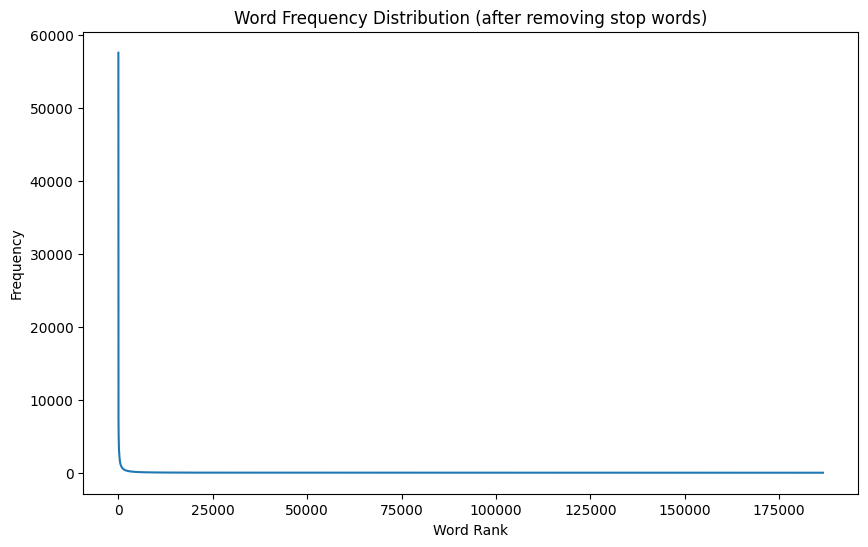

Average Text Length (after removing stop words): 59.52768945416004


In [27]:
from collections import Counter
import itertools
import matplotlib.pyplot as plt

# Tokenize the text data into words
all_words = list(itertools.chain.from_iterable([text.split() for text in X_train]))

# Vocabulary size
vocab_size = len(set(all_words))
print("Vocabulary Size (after removing stop words):", vocab_size)

# Word frequency distribution
word_counts = Counter(all_words)
print("Most Common Words (after removing stop words):", word_counts.most_common(10))

# Plot word frequency distribution
word_frequencies = [count for _, count in word_counts.most_common()]
plt.figure(figsize=(10, 6))
plt.plot(word_frequencies)
plt.title("Word Frequency Distribution (after removing stop words)")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.show()

# Average text length
text_lengths = [len(text.split()) for text in X_train_no_stopwords]
print("Average Text Length (after removing stop words):", sum(text_lengths) / len(text_lengths))

## Pipeline

In [ ]:
""" COPY OF THE CELL BELOW WITH SMALLER SEARCH SPACE (HYPERPARAMETERS) & FEWER CV FOLDS"""

#43 min VSCode 06.05.2025
#Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 10000, 'vectorizer__ngram_range': (1, 2)}
#Best Cross-Validation Score: 0.733400155822474
#Test Set Weighted F1 Score: 0.5435624022968075

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Example classifier
])

# Define the parameter grid
param_grid = {
    'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # French stop words are already removed
    'vectorizer__max_features': [5000, 7500, 10000],  # Example vectorizer hyperparameters
    'vectorizer__ngram_range': [(1, 2)],  # Unigrams and bigrams
    'classifier__n_estimators': [50, 100],  # Example classifier hyperparameters
    'classifier__max_depth': [None, 10, 20],  # Example classifier hyperparameters
}

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 10000, 'vectorizer__ngram_range': (1, 2)}
Best Cross-Validation Score: 0.733400155822474


## Testing the best parameters on test set

In [35]:
from sklearn.metrics import f1_score

# Predict on the test set
y_test_pred = best_model.predict(X_test)

# Calculate the weighted F1 score
test_f1_score = f1_score(y_test, y_test_pred, average='weighted')
print("Test Set Weighted F1 Score:", test_f1_score)

Test Set Weighted F1 Score: 0.5435624022968075


## All results

In [ ]:
import pandas as pd

# Convert cv_results_ to a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort the results by mean_test_score in descending order
cv_results_sorted = cv_results.sort_values(by='mean_test_score', ascending=False)

# Display the top results (parameters and scores)
print(cv_results_sorted[['mean_test_score', 'params']])

    mean_test_score                                             params
11         0.733400  {'classifier__max_depth': None, 'classifier__n...
5          0.730288  {'classifier__max_depth': None, 'classifier__n...
10         0.728371  {'classifier__max_depth': None, 'classifier__n...
8          0.726065  {'classifier__max_depth': None, 'classifier__n...
4          0.724341  {'classifier__max_depth': None, 'classifier__n...
7          0.722815  {'classifier__max_depth': None, 'classifier__n...
2          0.720131  {'classifier__max_depth': None, 'classifier__n...
9          0.718880  {'classifier__max_depth': None, 'classifier__n...
1          0.717565  {'classifier__max_depth': None, 'classifier__n...
3          0.714194  {'classifier__max_depth': None, 'classifier__n...
6          0.712804  {'classifier__max_depth': None, 'classifier__n...
0          0.708944  {'classifier__max_depth': None, 'classifier__n...
33         0.533236  {'classifier__max_depth': 20, 'classifier__n_e...
27    

## getting the nth best parameter

In [51]:
import numpy as np
import pandas as pd

# Convert cv_results_ to a DataFrame for easier manipulation
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort the results by mean_test_score in descending order
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)

# Retrieve the second-best model's parameters and score
n_plus_1_best_params = cv_results.iloc[12]['params']  # Second-best parameters
n_plus_1_best_score = cv_results.iloc[12]['mean_test_score']  # Second-best CV score

print("Second-Best Parameters:", n_plus_1_best_params)
print("Second-Best Cross-Validation Score:", n_plus_1_best_score)

Second-Best Parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 2)}
Second-Best Cross-Validation Score: 0.5332362754758104
